# KLTN — Baseline Replicate + Fix Data Leakage (V1.0 → V1.1)

**Đề tài:** Nhận diện hành vi bất thường trong siêu thị
**Notebook:** Train + so sánh 2 phiên bản baseline LSTM-CNN của Hảo

## Mục tiêu
1. **V1.0** — Replicate baseline Hảo: train_test_split ngẫu nhiên 80/20 → F1 dự kiến ≈ 0.85-0.87
2. **V1.1** — Fix data leakage: split theo clip_id (GroupShuffleSplit) → F1 dự kiến giảm xuống ≈ 0.70-0.78

→ Hai con số này được đưa vào báo cáo KLTN Chương 3.5.1 (ablation).

## Chuẩn bị trước khi chạy
1. Upload toàn bộ folder `Human-Reco/` lên Google Drive (giữ nguyên cấu trúc thư mục, không cần upload `.git/`).
2. Đảm bảo có `X_data.npy`, `y_data.npy`, và folder `processed_data/normal/`, `processed_data/shoplifting/`.
3. Chạy trên Colab với GPU T4 hoặc tốt hơn (Runtime → Change runtime type → T4 GPU).

## 1. Mount Google Drive và cấu hình đường dẫn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ★ SỬA đường dẫn này thành nơi bạn upload folder Human-Reco lên Drive
ROOT_DIR = "/content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco"

import os
assert os.path.exists(ROOT_DIR), f"Không thấy {ROOT_DIR}. Hãy upload folder Human-Reco lên Drive."
assert os.path.exists(f"{ROOT_DIR}/X_data.npy"), "Thiếu X_data.npy"
assert os.path.exists(f"{ROOT_DIR}/y_data.npy"), "Thiếu y_data.npy"
assert os.path.exists(f"{ROOT_DIR}/processed_data"), "Thiếu folder processed_data/"

# Output dir để lưu model + log
OUT_DIR = f"{ROOT_DIR}/training_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"ROOT_DIR = {ROOT_DIR}")
print(f"OUT_DIR  = {OUT_DIR}")

ROOT_DIR = /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco
OUT_DIR  = /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs


## 2. Cài đặt dependency

In [ ]:
import tensorflow as tf
import sklearn
import pandas as pd
import numpy as np

print(tf.__version__)
print(pd.__version__)
print(np.__version__)

2.20.0
2.2.2
2.0.2


In [ ]:
!pip install -q tensorflow scikit-learn pandas seaborn matplotlib numpy

In [ ]:
import os, json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     BatchNormalization, Dense, Reshape, Input, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Verify GPU
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Load X_data.npy và y_data.npy

In [ ]:
X = np.load(f"{ROOT_DIR}/X_data.npy")
y = np.load(f"{ROOT_DIR}/y_data.npy")
print(f"X.shape = {X.shape}, dtype = {X.dtype}")
print(f"y.shape = {y.shape}, dtype = {y.dtype}")
print(f"X min/max = {X.min():.4f} / {X.max():.4f}")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  class {u}: {c} mẫu ({100*c/len(y):.1f}%)")
print(f"\\n→ Hảo train trên shape này. Mỗi mẫu = 1 sliding window 90 frame × 34 features (17 keypoint × 2 toạ độ).")

X.shape = (1336, 90, 34), dtype = float32
y.shape = (1336,), dtype = int32
X min/max = 0.0000 / 1.0000
  class 0: 667 mẫu (49.9%)
  class 1: 669 mẫu (50.1%)
\n→ Hảo train trên shape này. Mỗi mẫu = 1 sliding window 90 frame × 34 features (17 keypoint × 2 toạ độ).


## 4. Tái tạo `clip_ids` từ folder `processed_data/`

`X_data.npy` được Hảo sinh bằng `prepare_data.py` với sliding window step=30 trên các file CSV trong `processed_data/`. Một video clip dài 90+ frame sinh ra nhiều mẫu chồng nhau **nhưng repo gốc không lưu id của clip nguồn**.

Ta tái tạo bằng cách chạy lại đúng logic của `prepare_data.py` và đánh nhãn clip_id = tên file CSV.

In [ ]:
def regenerate_with_clip_ids(processed_root, seq_length=90, step=30):
    """Replicate logic prepare_data.py của Hảo, kèm trả về clip_ids."""
    X, y, clip_ids = [], [], []
    for label_name in ['normal', 'shoplifting']:
        label_val = 0 if label_name == 'normal' else 1
        folder = os.path.join(processed_root, label_name)
        files = sorted(glob.glob(os.path.join(folder, "*.csv")))
        for fp in files:
            clip_id = f"{label_name}/{os.path.basename(fp)}"  # vd: "normal/normal-2.csv"
            data = pd.read_csv(fp).values
            for i in range(0, len(data) - seq_length + 1, step):
                X.append(data[i : i + seq_length])
                y.append(label_val)
                clip_ids.append(clip_id)
    X = np.array(X, dtype='float32')
    y = np.array(y, dtype='int')
    clip_ids = np.array(clip_ids)
    return X, y, clip_ids

X_re, y_re, clip_ids = regenerate_with_clip_ids(f"{ROOT_DIR}/processed_data")
print(f"Regenerated: X={X_re.shape}, y={y_re.shape}, clip_ids={clip_ids.shape}")
print(f"Số clip unique: {len(np.unique(clip_ids))}")
print(f"Mẫu / clip: mean={np.bincount(np.unique(clip_ids, return_inverse=True)[1]).mean():.1f}")

# Verify khớp với X_data.npy gốc
match_shape = X_re.shape == X.shape
match_y = (y_re == y).mean() if match_shape else 0
print(f"\\nShape khớp với X_data.npy gốc? {match_shape}")
print(f"y khớp 100%? {match_y == 1.0} ({match_y*100:.1f}%)")
if match_shape and match_y == 1.0:
    print("✓ X_re và y_re khớp với file gốc → clip_ids đáng tin")
else:
    print("⚠ KHÁC — có thể Hảo dùng order khác. Dùng X gốc và clip_ids vừa regenerate.")
    # Trường hợp khác: kiểm tra xem có thể là do shuffle

Regenerated: X=(1336, 90, 34), y=(1336,), clip_ids=(1336,)
Số clip unique: 155
Mẫu / clip: mean=8.6
\nShape khớp với X_data.npy gốc? True
y khớp 100%? True (100.0%)
✓ X_re và y_re khớp với file gốc → clip_ids đáng tin


In [ ]:
# Lưu clip_ids.npy
np.save(f"{ROOT_DIR}/clip_ids.npy", clip_ids)
print(f"✓ Đã lưu {ROOT_DIR}/clip_ids.npy")

# Bằng chứng leakage: phân tích bao nhiêu mẫu chia sẻ clip với mẫu khác
from collections import Counter
clip_counts = Counter(clip_ids)
shared_clip_samples = sum(c for c in clip_counts.values() if c > 1)
print(f"\\n=== BẰNG CHỨNG SLIDING WINDOW LEAKAGE ===")
print(f"Tổng số sample: {len(clip_ids)}")
print(f"Số clip unique: {len(clip_counts)}")
print(f"Sample chia sẻ clip với sample khác: {shared_clip_samples} ({100*shared_clip_samples/len(clip_ids):.1f}%)")
print(f"→ Random split sẽ leak {100*shared_clip_samples/len(clip_ids):.1f}% sample.")

✓ Đã lưu /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/clip_ids.npy
\n=== BẰNG CHỨNG SLIDING WINDOW LEAKAGE ===
Tổng số sample: 1336
Số clip unique: 155
Sample chia sẻ clip với sample khác: 1336 (100.0%)
→ Random split sẽ leak 100.0% sample.


## 5. Định nghĩa mô hình LSTM-CNN Hybrid (giống Hảo)

Kiến trúc Hảo trong `KLTN.ipynb`: 2× LSTM(32) → Reshape → 2× Conv2D → GAP → BatchNorm → Dense(2).
Tổng ~93K tham số. **Giữ nguyên** để fair comparison.

In [ ]:
def build_hybrid_model(input_shape=(90, 34), num_classes=2):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(32, return_sequences=True),
        LSTM(32, return_sequences=True),
        Reshape((90, 32, 1)),
        Conv2D(64, kernel_size=(5, 5), strides=(2, 2), padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        Conv2D(128, kernel_size=(3, 3), strides=(1, 1), padding='same', activation='relu'),
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(num_classes, activation='softmax'),
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

build_hybrid_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 32)         │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 90, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 90, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 45, 16, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,186 (364.01 KB)

 Trainable params: 92,930 (363.01 KB)

 Non-trainable params: 256 (1.00 KB)

## 6. Hàm train chung cho cả V1.0 và V1.1

In [ ]:
def train_one_config(X_train, y_train, X_val, y_val, X_test, y_test,
                     config_name, save_dir, epochs=100, batch_size=64, verbose=2):
    """Train + eval một config. Trả về dict kết quả."""
    print(f"\\n{'='*70}")
    print(f"=== Training {config_name} ===")
    print(f"{'='*70}")
    print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

    model = build_hybrid_model()
    model_path = f"{save_dir}/best_{config_name}.keras"
    callbacks = [
        ModelCheckpoint(model_path, monitor='val_loss', save_best_only=True, verbose=0),
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ]

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose,
    )
    train_time = time.time() - t0

    # Eval on test
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    report = classification_report(y_test, y_pred, target_names=['Normal', 'Shoplifting'], digits=4)
    cm = confusion_matrix(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')

    print(f"\\n[Test classification report]\\n{report}")
    print(f"Confusion matrix:\\n{cm}")
    print(f"F1-macro on TEST: {f1m:.4f}")
    print(f"Training time: {train_time:.1f}s")

    # Save log
    log = {
        "config": config_name,
        "train_size": int(X_train.shape[0]),
        "val_size": int(X_val.shape[0]),
        "test_size": int(X_test.shape[0]),
        "epochs_trained": len(history.history['loss']),
        "best_val_loss": float(min(history.history['val_loss'])),
        "test_f1_macro": float(f1m),
        "test_confusion_matrix": cm.tolist(),
        "test_classification_report": report,
        "train_time_sec": train_time,
        "history": {k: [float(v) for v in vs] for k, vs in history.history.items()},
    }
    with open(f"{save_dir}/log_{config_name}.json", "w") as f:
        json.dump(log, f, indent=2, ensure_ascii=False)
    print(f"✓ Đã lưu {model_path} và log_{config_name}.json")

    return log, history, cm

## 7. V1.0 — Train với random split 80/20 (replicate Hảo)

Đây là cách Hảo đang làm. Tách thêm validation set (10%) để theo dõi và early stop.

In [ ]:
# Random split 80/20 (như Hảo), sau đó tách validation 10% từ train
X_temp, X_test_v10, y_temp, y_test_v10 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train_v10, X_val_v10, y_train_v10, y_val_v10 = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
)
# Tỉ lệ cuối: 70% train, 10% val, 20% test
print(f"Train: {X_train_v10.shape[0]} | Val: {X_val_v10.shape[0]} | Test: {X_test_v10.shape[0]}")

log_v10, hist_v10, cm_v10 = train_one_config(
    X_train_v10, y_train_v10,
    X_val_v10, y_val_v10,
    X_test_v10, y_test_v10,
    config_name="v1.0_random_split",
    save_dir=OUT_DIR,
    epochs=100,
)

Train: 934 | Val: 134 | Test: 268
\n======================================================================
=== Training v1.0_random_split ===
Train: 934, Val: 134, Test: 268
Epoch 1/100
15/15 - 11s - 710ms/step - accuracy: 0.5600 - loss: 0.6881 - val_accuracy: 0.5000 - val_loss: 0.6929 - learning_rate: 1.0000e-04
Epoch 2/100
15/15 - 5s - 305ms/step - accuracy: 0.5899 - loss: 0.6762 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 1.0000e-04
Epoch 3/100
15/15 - 0s - 26ms/step - accuracy: 0.6231 - loss: 0.6612 - val_accuracy: 0.5000 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 4/100
15/15 - 0s - 25ms/step - accuracy: 0.6734 - loss: 0.6415 - val_accuracy: 0.5000 - val_loss: 0.6912 - learning_rate: 1.0000e-04
Epoch 5/100
15/15 - 0s - 25ms/step - accuracy: 0.6820 - loss: 0.6216 - val_accuracy: 0.5000 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 6/100
15/15 - 0s - 24ms/step - accuracy: 0.6906 - loss: 0.6069 - val_accuracy: 0.5000 - val_loss: 0.6863 - learning_rate: 

## 8. V1.1 — Train với split-by-clip (FIX data leakage)

Dùng `GroupShuffleSplit` từ sklearn để chia 70/15/15 theo `clip_ids`. Khẳng định không có clip_id chung giữa train/val/test trước khi train.

In [ ]:
# Step 1: chia train (70%) vs (val+test) (30%)
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=SEED)
idx_train, idx_rem = next(gss1.split(X, y, groups=clip_ids))

# Step 2: trong (val+test), chia val:test = 50:50 → mỗi cái 15%
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED+1)
idx_val_local, idx_test_local = next(gss2.split(
    X[idx_rem], y[idx_rem], groups=clip_ids[idx_rem]
))
idx_val = idx_rem[idx_val_local]
idx_test = idx_rem[idx_test_local]

X_train_v11, y_train_v11 = X[idx_train], y[idx_train]
X_val_v11, y_val_v11 = X[idx_val], y[idx_val]
X_test_v11, y_test_v11 = X[idx_test], y[idx_test]

# Khẳng định không leak
clips_train = set(clip_ids[idx_train])
clips_val = set(clip_ids[idx_val])
clips_test = set(clip_ids[idx_test])
assert not (clips_train & clips_val), f"LEAK train↔val: {clips_train & clips_val}"
assert not (clips_train & clips_test), f"LEAK train↔test: {clips_train & clips_test}"
assert not (clips_val & clips_test), f"LEAK val↔test: {clips_val & clips_test}"
print(f"✓ KHÔNG có clip_id chung giữa 3 tập.")
print(f"  Train: {len(clips_train)} clip → {len(idx_train)} mẫu")
print(f"  Val:   {len(clips_val)} clip → {len(idx_val)} mẫu")
print(f"  Test:  {len(clips_test)} clip → {len(idx_test)} mẫu")

# Phân bố class trong test (check imbalance)
print(f"\\nPhân bố class trong test:")
u, c = np.unique(y_test_v11, return_counts=True)
for ui, ci in zip(u, c):
    print(f"  class {ui}: {ci} ({100*ci/len(y_test_v11):.1f}%)")

✓ KHÔNG có clip_id chung giữa 3 tập.
  Train: 108 clip → 931 mẫu
  Val:   23 clip → 192 mẫu
  Test:  24 clip → 213 mẫu
\nPhân bố class trong test:
  class 0: 121 (56.8%)
  class 1: 92 (43.2%)


In [ ]:
log_v11, hist_v11, cm_v11 = train_one_config(
    X_train_v11, y_train_v11,
    X_val_v11, y_val_v11,
    X_test_v11, y_test_v11,
    config_name="v1.1_split_by_clip",
    save_dir=OUT_DIR,
    epochs=100,
)

\n======================================================================
=== Training v1.1_split_by_clip ===
Train: 931, Val: 192, Test: 213
Epoch 1/100
15/15 - 4s - 242ms/step - accuracy: 0.5521 - loss: 0.6879 - val_accuracy: 0.3906 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 2/100
15/15 - 0s - 19ms/step - accuracy: 0.5951 - loss: 0.6738 - val_accuracy: 0.4219 - val_loss: 0.6938 - learning_rate: 1.0000e-04
Epoch 3/100
15/15 - 0s - 21ms/step - accuracy: 0.6423 - loss: 0.6582 - val_accuracy: 0.4375 - val_loss: 0.6940 - learning_rate: 1.0000e-04
Epoch 4/100
15/15 - 0s - 18ms/step - accuracy: 0.7078 - loss: 0.6346 - val_accuracy: 0.4635 - val_loss: 0.6943 - learning_rate: 1.0000e-04
Epoch 5/100
15/15 - 0s - 19ms/step - accuracy: 0.7293 - loss: 0.6032 - val_accuracy: 0.4896 - val_loss: 0.6943 - learning_rate: 1.0000e-04
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
15/15 - 0s - 18ms/step - accuracy: 0.7530 - loss: 0.5756 - val_accuracy: 0

## 9. So sánh V1.0 vs V1.1 — Chứng minh data leakage

Đây là bảng quan trọng nhất cho báo cáo KLTN Chương 3.5.1.

In [ ]:
print("="*70)
print("BẢNG SO SÁNH V1.0 (random split) vs V1.1 (split-by-clip)")
print("="*70)
print(f"{'Metric':<25} | {'V1.0 random':>15} | {'V1.1 by-clip':>15} | {'Δ':>10}")
print("-"*70)
def row(name, v10, v11):
    delta = v11 - v10
    print(f"{name:<25} | {v10:>15.4f} | {v11:>15.4f} | {delta:>+10.4f}")
row("F1-macro (test)", log_v10["test_f1_macro"], log_v11["test_f1_macro"])
row("Best val_loss", log_v10["best_val_loss"], log_v11["best_val_loss"])

print()
print(f"→ V1.0 F1 = {log_v10['test_f1_macro']:.4f} — kết quả 'có leakage' của Hảo")
print(f"→ V1.1 F1 = {log_v11['test_f1_macro']:.4f} — kết quả THẬT khi không có leakage")
print(f"→ Chênh lệch: {(log_v10['test_f1_macro'] - log_v11['test_f1_macro'])*100:+.1f} điểm phần trăm")

BẢNG SO SÁNH V1.0 (random split) vs V1.1 (split-by-clip)
Metric                    |     V1.0 random |    V1.1 by-clip |          Δ
----------------------------------------------------------------------
F1-macro (test)           |          0.7658 |          0.5526 |    -0.2132
Best val_loss             |          0.5012 |          0.6890 |    +0.1878

→ V1.0 F1 = 0.7658 — kết quả 'có leakage' của Hảo
→ V1.1 F1 = 0.5526 — kết quả THẬT khi không có leakage
→ Chênh lệch: +21.3 điểm phần trăm


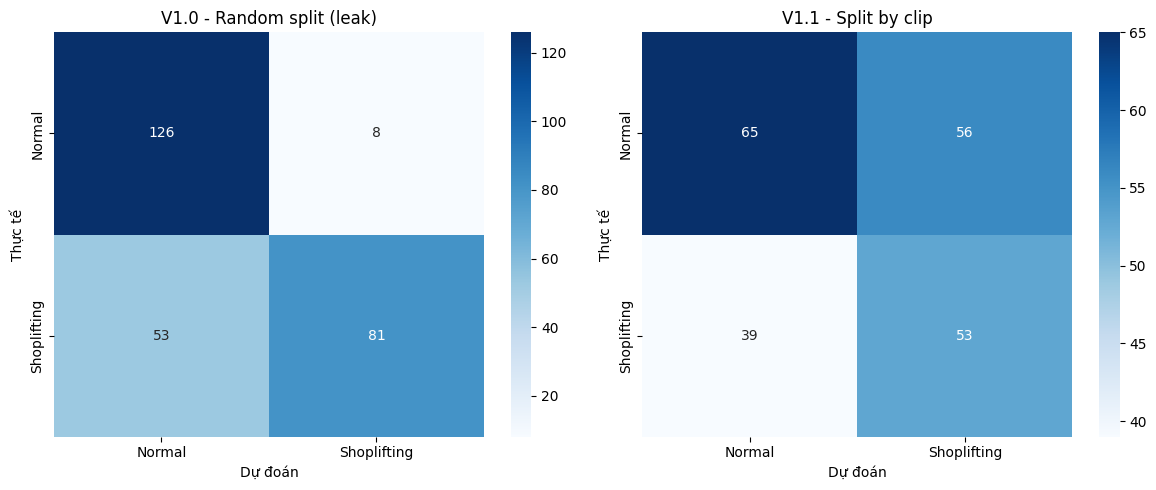

✓ Đã lưu /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/cm_comparison.png


In [ ]:
# Vẽ confusion matrix kép
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in zip(axes, [cm_v10, cm_v11],
                          ["V1.0 - Random split (leak)", "V1.1 - Split by clip"]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Shoplifting'],
                yticklabels=['Normal', 'Shoplifting'], ax=ax)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')
    ax.set_title(title)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/cm_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Đã lưu {OUT_DIR}/cm_comparison.png")

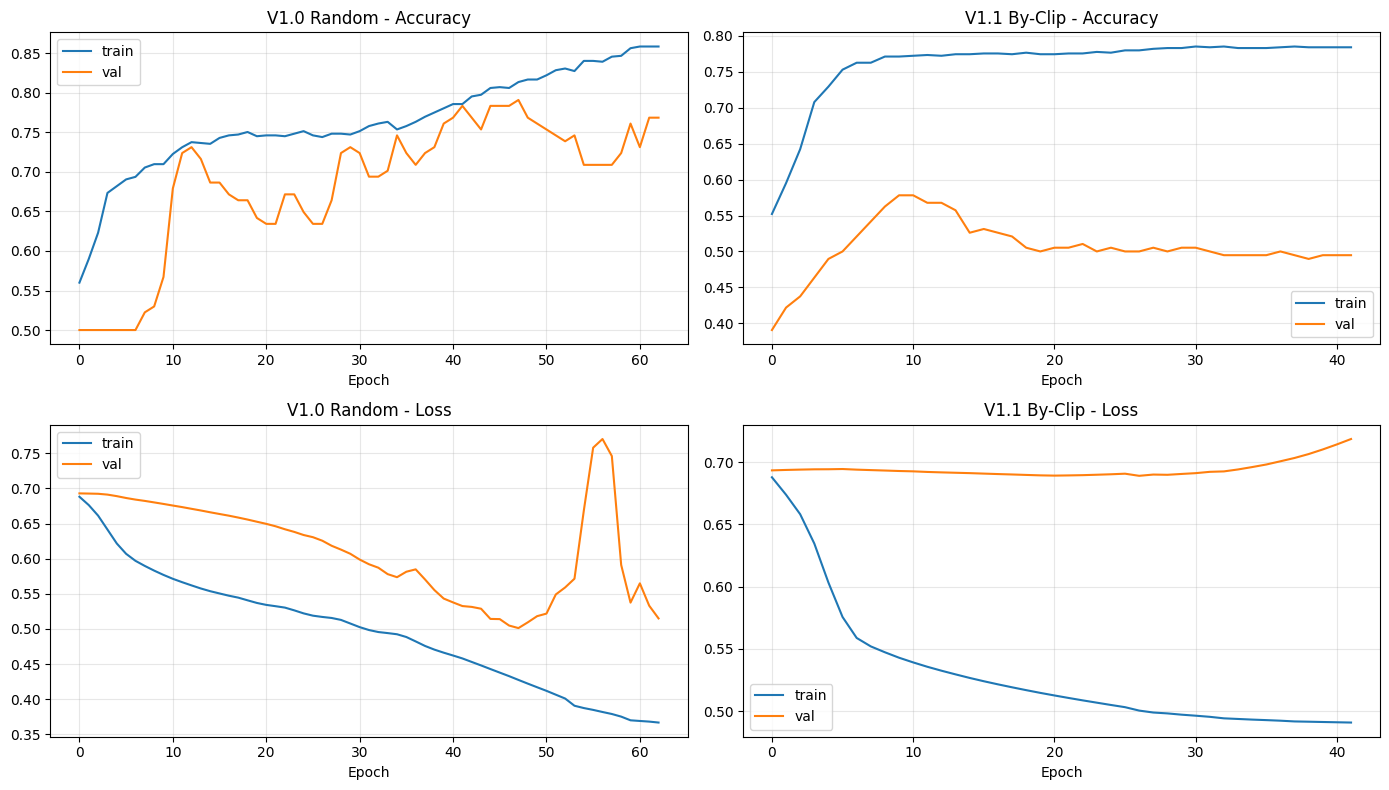

✓ Đã lưu /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/training_curves.png


In [ ]:
# Vẽ accuracy & loss curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for col, (hist, name) in enumerate([(hist_v10, "V1.0 Random"), (hist_v11, "V1.1 By-Clip")]):
    axes[0, col].plot(hist.history['accuracy'], label='train')
    axes[0, col].plot(hist.history['val_accuracy'], label='val')
    axes[0, col].set_title(f'{name} - Accuracy')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(hist.history['loss'], label='train')
    axes[1, col].plot(hist.history['val_loss'], label='val')
    axes[1, col].set_title(f'{name} - Loss')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Đã lưu {OUT_DIR}/training_curves.png")

## 10. Lưu báo cáo tổng kết

In [ ]:
summary = {
    "experiment_date": time.strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": {
        "X_shape": list(X.shape),
        "y_shape": list(y.shape),
        "num_clips": int(len(np.unique(clip_ids))),
        "samples_sharing_clip_pct": round(100*shared_clip_samples/len(clip_ids), 2),
    },
    "model": "LSTM-CNN Hybrid (Hảo's architecture, ~93K params)",
    "v1_0_random_split": {
        "f1_macro": log_v10["test_f1_macro"],
        "test_size": log_v10["test_size"],
        "epochs_trained": log_v10["epochs_trained"],
        "note": "Replicate Hảo (có thể leakage do sliding window step=30)",
    },
    "v1_1_split_by_clip": {
        "f1_macro": log_v11["test_f1_macro"],
        "test_size": log_v11["test_size"],
        "epochs_trained": log_v11["epochs_trained"],
        "note": "Fix leakage với GroupShuffleSplit theo clip_id",
    },
    "delta_f1": log_v10["test_f1_macro"] - log_v11["test_f1_macro"],
    "conclusion": (
        f"V1.0 F1={log_v10['test_f1_macro']:.4f}, V1.1 F1={log_v11['test_f1_macro']:.4f}. "
        f"Khoảng cách {abs(log_v10['test_f1_macro']-log_v11['test_f1_macro'])*100:.1f}% đo mức độ leakage."
    ),
}

import json
with open(f"{OUT_DIR}/V1_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f"\\n✓ Đã lưu {OUT_DIR}/V1_summary.json")
print("\\nFILE TRONG OUT_DIR:")
for f in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUT_DIR, f)) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

{
  "experiment_date": "2026-05-19 05:27:39",
  "dataset": {
    "X_shape": [
      1336,
      90,
      34
    ],
    "y_shape": [
      1336
    ],
    "num_clips": 155,
    "samples_sharing_clip_pct": 100.0
  },
  "model": "LSTM-CNN Hybrid (Hảo's architecture, ~93K params)",
  "v1_0_random_split": {
    "f1_macro": 0.7657846100947006,
    "test_size": 268,
    "epochs_trained": 63,
    "note": "Replicate Hảo (có thể leakage do sliding window step=30)"
  },
  "v1_1_split_by_clip": {
    "f1_macro": 0.5525704809286899,
    "test_size": 213,
    "epochs_trained": 42,
    "note": "Fix leakage với GroupShuffleSplit theo clip_id"
  },
  "delta_f1": 0.21321412916601068,
  "conclusion": "V1.0 F1=0.7658, V1.1 F1=0.5526. Khoảng cách 21.3% đo mức độ leakage."
}
\n✓ Đã lưu /content/drive/MyDrive/KLTN_KTDL_Nhom28/Human-Reco/training_outputs/V1_summary.json
\nFILE TRONG OUT_DIR:
  V1_summary.json  (0.8 KB)
  best_v1.0_random_split.keras  (1144.2 KB)
  best_v1.1_split_by_clip.keras  (1144.2 KB)
 

## 11. Bước tiếp theo

Sau khi notebook này chạy xong, bạn sẽ có:

- `best_v1.0_random_split.keras` + `log_v1.0_random_split.json`
- `best_v1.1_split_by_clip.keras` + `log_v1.1_split_by_clip.json`
- `cm_comparison.png`, `training_curves.png`, `V1_summary.json`

**Cập nhật báo cáo KLTN:**
- Chương 3.3 (kết quả Stage 4) sẽ có bảng 2 dòng V1.0 vs V1.1.
- Phần "Thảo luận" (3.7) phân tích tác động data leakage.

**Bước 2 (V1.2):** Train với 56 đặc trưng hình học (`processed_data1/`), kèm split by clip.
**Bước 3 (V2.0):** Port sang PyTorch + torch_geometric, thay LSTM-CNN bằng **ST-GCN + Temporal Transformer** — đóng góp học thuật chính.

Khi V1.0+V1.1 xong, gửi 2 file JSON log cho tôi → tôi sẽ điền số vào Chương 3 của báo cáo KLTN.docx.